<a href="https://colab.research.google.com/github/baghelrashmi04/Smart-EV-grid-optmization-Demand-Engine/blob/main/grid_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## used libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/charging_ev_and_grid_optimization_dataset.csv")
df=df.drop(columns='timestamp')
df

,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,48.984550,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,58.495493,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,35.711722,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,29.270825,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,25.585554,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,ST011,Urban,EV18349,Bus,3/28/2025 23:15,3/28/2025 23:28,3/28/2025 23:52,13,30,59.057523,...,14.67,0.131198,Low,Clear,Friday,Off-Peak,24.557664,CH6,Low,-15.495699
8350,ST019,Urban,EV18350,Two-Wheeler,3/28/2025 23:30,3/28/2025 23:42,3/29/2025 0:50,12,30,58.544808,...,8.24,0.126224,Low,Cloudy,Friday,Off-Peak,33.027807,CH2,Medium,-14.885047
8351,ST005,Highway,EV18351,Bus,3/28/2025 23:45,3/28/2025 23:55,3/29/2025 7:00,10,75,33.857844,...,9.90,0.370010,Low,Cloudy,Friday,Off-Peak,27.381072,CH7,Medium,-5.713488
8352,ST014,Highway,EV18352,Two-Wheeler,3/29/2025 0:00,3/29/2025 0:22,3/29/2025 1:45,22,40,28.068288,...,14.85,0.105252,Low,Cloudy,Saturday,Off-Peak,25.138820,CH1,High,-27.040944


In [ ]:
df.describe()
df.dtypes
df['vehicle_type'].value_counts()

,count
vehicle_type,
Car,2833
Two-Wheeler,2761
Bus,2760


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## checking for missing values in numerical columns

numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numerical columns:", numerical_cols)
df[numerical_cols].isna().sum()

Numerical columns: ['waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'charging_demand', 'optimization_reward']


,0
waiting_time,0
battery_capacity_kWh,0
initial_soc,0
final_soc,0
energy_consumed_kWh,0
charging_power_kW,0
charging_duration,0
queue_length,0
station_load,0
electricity_price,0


In [ ]:
# checking for missing  values  in categorial columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)
df[categorical_cols].isna().sum()

Categorical columns: ['station_id', 'location_type', 'vehicle_id', 'vehicle_type', 'arrival_time', 'charging_start_time', 'charging_end_time', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'assigned_charger_id', 'charging_priority']


,0
station_id,0
location_type,0
vehicle_id,0
vehicle_type,0
arrival_time,0
charging_start_time,0
charging_end_time,0
traffic_density,0
weather_condition,0
day_of_week,0


In [ ]:
# checking for negetive values for numerical values

(df[numerical_cols] < 0).sum()
df

,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,48.984550,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,58.495493,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,35.711722,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,29.270825,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,25.585554,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,ST011,Urban,EV18349,Bus,3/28/2025 23:15,3/28/2025 23:28,3/28/2025 23:52,13,30,59.057523,...,14.67,0.131198,Low,Clear,Friday,Off-Peak,24.557664,CH6,Low,-15.495699
8350,ST019,Urban,EV18350,Two-Wheeler,3/28/2025 23:30,3/28/2025 23:42,3/29/2025 0:50,12,30,58.544808,...,8.24,0.126224,Low,Cloudy,Friday,Off-Peak,33.027807,CH2,Medium,-14.885047
8351,ST005,Highway,EV18351,Bus,3/28/2025 23:45,3/28/2025 23:55,3/29/2025 7:00,10,75,33.857844,...,9.90,0.370010,Low,Cloudy,Friday,Off-Peak,27.381072,CH7,Medium,-5.713488
8352,ST014,Highway,EV18352,Two-Wheeler,3/29/2025 0:00,3/29/2025 0:22,3/29/2025 1:45,22,40,28.068288,...,14.85,0.105252,Low,Cloudy,Saturday,Off-Peak,25.138820,CH1,High,-27.040944


In [ ]:
df.describe()

,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward
count,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,9.526335,61.079722,34.808452,98.495545,39.079746,22.449126,178.700376,4.591573,53.177399,9.959945,0.354101,53.156126,-11.834559
std,4.894049,25.001163,14.478839,3.258039,18.973883,16.813449,149.120567,2.828987,27.380740,2.878798,0.186150,27.563387,9.271940
min,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.000000,0.000000,10.053024,5.000000,0.100157,5.505723,-43.285910
25%,6.000000,40.000000,22.371986,98.463666,23.675251,11.000000,64.118008,3.000000,28.029710,7.510000,0.207315,27.911603,-18.354606
50%,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,133.700252,5.000000,49.421293,9.955000,0.313459,49.513337,-11.268337
75%,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,247.946169,7.000000,77.600445,12.397500,0.462315,77.845036,-5.106912
max,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,776.551110,15.000000,100.000000,15.000000,0.799922,104.985659,14.176434


In [ ]:
# feature engineering , converting timestamps columns in acture hours , days records

df['arrival_time'] = pd.to_datetime(df['arrival_time'])
df['charging_start_time'] = pd.to_datetime(df['charging_start_time'])
df['charging_end_time'] = pd.to_datetime(df['charging_end_time'])
df['total_charging_time'] = (df['charging_end_time'] - df['charging_start_time']).dt.total_seconds() / 3600

df[['arrival_time', 'charging_start_time', 'charging_end_time','waiting_time','total_charging_time']].head()

,arrival_time,charging_start_time,charging_end_time,waiting_time,total_charging_time
0,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,4.350000
1,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,0.816667
2,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,0.900000
3,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,2.583333
4,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,5.100000


In [ ]:
# calculating which day of the week the load spikes

df['arrival_day_of_week'] = df['arrival_time'].dt.dayofweek
df['charging_start_day_of_week'] = df['charging_start_time'].dt.dayofweek
df['charging_end_day_of_week'] = df['charging_end_time'].dt.dayofweek

df[['arrival_time', 'charging_start_time', 'charging_end_time','arrival_day_of_week','charging_start_day_of_week','charging_end_day_of_week']].head()


,arrival_time,charging_start_time,charging_end_time,arrival_day_of_week,charging_start_day_of_week,charging_end_day_of_week
0,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,2,2,2
1,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,2,2,2
2,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,2,2,2
3,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,2,2,2
4,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,2,2,2


In [ ]:
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['arrival_day_of_week_name'] = df['arrival_day_of_week'].map(lambda x: day_names[x])

df[['arrival_time', 'arrival_day_of_week', 'arrival_day_of_week_name']].head()

,arrival_time,arrival_day_of_week,arrival_day_of_week_name
0,2025-01-01 00:00:00,2,Wednesday
1,2025-01-01 00:15:00,2,Wednesday
2,2025-01-01 00:30:00,2,Wednesday
3,2025-01-01 00:45:00,2,Wednesday
4,2025-01-01 01:00:00,2,Wednesday


In [ ]:

df['arrival_hour'] = df['arrival_time'].dt.hour
df['charging_start_hour'] = df['charging_start_time'].dt.hour

df[['arrival_time', 'arrival_hour', 'arrival_day_of_week_name', 'electricity_price', 'waiting_time']].head()


,arrival_time,arrival_hour,arrival_day_of_week_name,electricity_price,waiting_time
0,2025-01-01 00:00:00,0,Wednesday,13.66,12
1,2025-01-01 00:15:00,0,Wednesday,5.47,8
2,2025-01-01 00:30:00,0,Wednesday,9.50,11
3,2025-01-01 00:45:00,0,Wednesday,6.22,9
4,2025-01-01 01:00:00,1,Wednesday,13.42,8


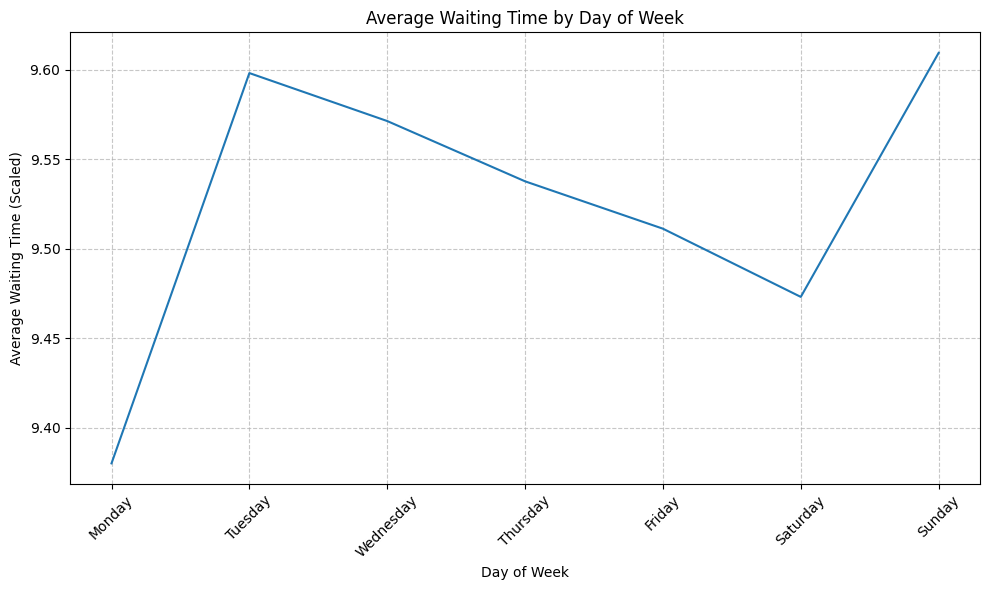

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# First, calculate the average waiting time per day of the week
avg_waiting_time_by_day_plot = df.groupby('arrival_day_of_week_name')['waiting_time'].mean().reset_index()

# Ensure the days are plotted in the correct order (Monday to Sunday)
day_names_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_waiting_time_by_day_plot['arrival_day_of_week_name'] = pd.Categorical(
    avg_waiting_time_by_day_plot['arrival_day_of_week_name'], categories=day_names_ordered, ordered=True
)
avg_waiting_time_by_day_plot = avg_waiting_time_by_day_plot.sort_values('arrival_day_of_week_name')

# Now plot the average waiting time by day of week using lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(x='arrival_day_of_week_name', y='waiting_time', data=avg_waiting_time_by_day_plot)
plt.title('Average Waiting Time by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Waiting Time (Scaled)')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_842/4263763917.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='arrival_day_of_week_name', y='waiting_time', data=df, palette='viridis')


The day of the week with the highest average waiting time is Sunday.


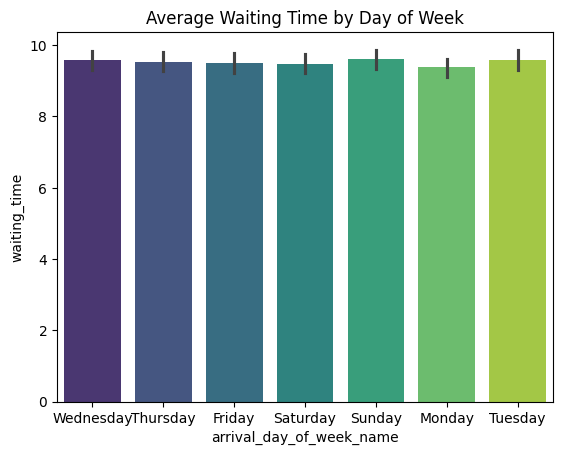

In [ ]:
## the maximum rush day of the week with waiting time

rush_day_of_week = df.groupby('arrival_day_of_week_name')['waiting_time'].mean().idxmax()
#plt.plot.figure(figsize=(10, 6))
sns.barplot(x='arrival_day_of_week_name', y='waiting_time', data=df, palette='viridis')
plt.title('Average Waiting Time by Day of Week')

print(f"The day of the week with the highest average waiting time is {rush_day_of_week}.")

In [ ]:
# At what days of the week does grid load hit its maximum — weekdays vs weekends?


# Convert timestamp column to datetime object
df['arrival_time'] = pd.to_datetime(df['arrival_time'])

# Extract day of the week (0 = Monday, 6 = Sunday)
df['day_of_week'] = df['arrival_time'].dt.dayofweek

# Create a boolean flag for Weekday (1) vs Weekend (0)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df


,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,...,charging_priority,optimization_reward,total_charging_time,arrival_day_of_week,charging_start_day_of_week,charging_end_day_of_week,arrival_day_of_week_name,arrival_hour,charging_start_hour,is_weekend
0,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,48.984550,...,Low,-8.622299,4.350000,2,2,2,Wednesday,0,0,0
1,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,58.495493,...,Low,-1.935644,0.816667,2,2,2,Wednesday,0,0,0
2,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,35.711722,...,Low,-18.201846,0.900000,2,2,2,Wednesday,0,0,0
3,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,29.270825,...,Medium,-7.404018,2.583333,2,2,2,Wednesday,0,0,0
4,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,25.585554,...,Low,-6.577466,5.100000,2,2,2,Wednesday,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,ST011,Urban,EV18349,Bus,2025-03-28 23:15:00,2025-03-28 23:28:00,2025-03-28 23:52:00,13,30,59.057523,...,Low,-15.495699,0.400000,4,4,4,Friday,23,23,0
8350,ST019,Urban,EV18350,Two-Wheeler,2025-03-28 23:30:00,2025-03-28 23:42:00,2025-03-29 00:50:00,12,30,58.544808,...,Medium,-14.885047,1.133333,4,4,5,Friday,23,23,0
8351,ST005,Highway,EV18351,Bus,2025-03-28 23:45:00,2025-03-28 23:55:00,2025-03-29 07:00:00,10,75,33.857844,...,Medium,-5.713488,7.083333,4,4,5,Friday,23,23,0
8352,ST014,Highway,EV18352,Two-Wheeler,2025-03-29 00:00:00,2025-03-29 00:22:00,2025-03-29 01:45:00,22,40,28.068288,...,High,-27.040944,1.383333,5,5,5,Saturday,0,0,1


adding features lag_1_hr, lag_2_hr,rolling_avg_3hr for model prediction

In [ ]:
df

,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,48.984550,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,58.495493,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,35.711722,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,29.270825,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,25.585554,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,ST011,Urban,EV18349,Bus,3/28/2025 23:15,3/28/2025 23:28,3/28/2025 23:52,13,30,59.057523,...,14.67,0.131198,Low,Clear,Friday,Off-Peak,24.557664,CH6,Low,-15.495699
8350,ST019,Urban,EV18350,Two-Wheeler,3/28/2025 23:30,3/28/2025 23:42,3/29/2025 0:50,12,30,58.544808,...,8.24,0.126224,Low,Cloudy,Friday,Off-Peak,33.027807,CH2,Medium,-14.885047
8351,ST005,Highway,EV18351,Bus,3/28/2025 23:45,3/28/2025 23:55,3/29/2025 7:00,10,75,33.857844,...,9.90,0.370010,Low,Cloudy,Friday,Off-Peak,27.381072,CH7,Medium,-5.713488
8352,ST014,Highway,EV18352,Two-Wheeler,3/29/2025 0:00,3/29/2025 0:22,3/29/2025 1:45,22,40,28.068288,...,14.85,0.105252,Low,Cloudy,Saturday,Off-Peak,25.138820,CH1,High,-27.040944


In [ ]:
import pandas as pd

# 1. Ensure datetime format
df['arrival_time'] = pd.to_datetime(df['arrival_time'])

# 2. Resample data into strict 1-hour buckets per station
hourly_df = (
    df.set_index('arrival_time')
      .groupby('station_id')[['station_load', 'charging_demand', 'electricity_price']]
      .resample('1h')  # Creates a row for EVERY single hour
      .mean()          # Average load during that hour
      .ffill()         # Forward-fill hours where no new cars arrived
      .reset_index()
)

# 3. NOW .shift(1) means EXACTLY 1 hour ago!
hourly_df['lag_1_hr_station_load'] = hourly_df.groupby('station_id')['station_load'].shift(1)
hourly_df['lag_2_hr_station_load'] = hourly_df.groupby('station_id')['station_load'].shift(2)
hourly_df['lag_3_hr_station_load'] = hourly_df.groupby('station_id')['station_load'].shift(3)
hourly_df['lag_24_hr_station_load'] = hourly_df.groupby('station_id')['station_load'].shift(24)

In [ ]:
#Remove the existing lag_1_hr_station_load from df
# (It will be re-added from hourly_df)
if 'lag_1_hr_station_load' in df.columns:
    df = df.drop(columns=['lag_1_hr_station_load'])

# 2. Create a time key in df for merging with hourly_df
df['hourly_arrival_time_key'] = df['arrival_time'].dt.floor('H')

# 3. Select and rename columns from hourly_df for merging
hourly_lag_data = hourly_df[['station_id', 'arrival_time', 'lag_1_hr_station_load']].rename(
    columns={'arrival_time': 'hourly_arrival_time_key', 'lag_1_hr_station_load': 'new_lag_1_hr_station_load'}
)

# 4. Merge the hourly lagged data into df
df = pd.merge(
    df,
    hourly_lag_data,
    on=['station_id', 'hourly_arrival_time_key'],
    how='left'
)

# 5. Rename the new column and drop the temporary key
df = df.rename(columns={'new_lag_1_hr_station_load': 'lag_1_hr_station_load'})
df = df.drop(columns=['hourly_arrival_time_key'])

# Fill any NaN values that might result from the merge for the lag column (e.g., first few entries)
df['lag_1_hr_station_load'] = df['lag_1_hr_station_load'].fillna(0)

print("DataFrame with updated 'lag_1_hr_station_load' from hourly averages:")
display(df[['station_id', 'arrival_time', 'station_load', 'lag_1_hr_station_load']].head(20))

DataFrame with updated 'lag_1_hr_station_load' from hourly averages:


/tmp/ipykernel_842/2176191312.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['hourly_arrival_time_key'] = df['arrival_time'].dt.floor('H')


,station_id,arrival_time,station_load,lag_1_hr_station_load
0,ST004,2025-01-01 00:00:00,15.161672,0.000000
1,ST005,2025-01-01 00:15:00,20.997219,0.000000
2,ST019,2025-01-01 00:30:00,31.606151,0.000000
3,ST008,2025-01-01 00:45:00,21.803050,0.000000
4,ST008,2025-01-01 01:00:00,15.626266,21.803050
5,ST014,2025-01-01 01:15:00,20.416685,0.000000
6,ST004,2025-01-01 01:30:00,15.305339,15.161672
7,ST020,2025-01-01 01:45:00,18.480893,0.000000
8,ST004,2025-01-01 02:00:00,23.658538,15.305339
9,ST020,2025-01-01 02:15:00,16.034384,18.480893


In [ ]:
# Create a time key in df for merging with hourly_df (needed at the start of this cell)
df['hourly_arrival_time_key'] = df['arrival_time'].dt.floor('H')

# Update lag_2_hr_station_load
if 'lag_2_hr_station_load' in df.columns:
    df = df.drop(columns=['lag_2_hr_station_load'])
hourly_lag_data_2hr = hourly_df[['station_id', 'arrival_time', 'lag_2_hr_station_load']].rename(
    columns={'arrival_time': 'hourly_arrival_time_key', 'lag_2_hr_station_load': 'new_lag_2_hr_station_load'}
)
df = pd.merge(
    df,
    hourly_lag_data_2hr,
    on=['station_id', 'hourly_arrival_time_key'],
    how='left'
)
df = df.rename(columns={'new_lag_2_hr_station_load': 'lag_2_hr_station_load'})
df['lag_2_hr_station_load'] = df['lag_2_hr_station_load'].fillna(0)

# Update lag_3_hr_station_load
if 'lag_3_hr_station_load' in df.columns:
    df = df.drop(columns=['lag_3_hr_station_load'])
hourly_lag_data_3hr = hourly_df[['station_id', 'arrival_time', 'lag_3_hr_station_load']].rename(
    columns={'arrival_time': 'hourly_arrival_time_key', 'lag_3_hr_station_load': 'new_lag_3_hr_station_load'}
)
df = pd.merge(
    df,
    hourly_lag_data_3hr,
    on=['station_id', 'hourly_arrival_time_key'],
    how='left'
)
df = df.rename(columns={'new_lag_3_hr_station_load': 'lag_3_hr_station_load'})
df['lag_3_hr_station_load'] = df['lag_3_hr_station_load'].fillna(0)

# Update lag_24_hr_station_load
if 'lag_24_hr_station_load' in df.columns:
    df = df.drop(columns=['lag_24_hr_station_load'])
hourly_lag_data_24hr = hourly_df[['station_id', 'arrival_time', 'lag_24_hr_station_load']].rename(
    columns={'arrival_time': 'hourly_arrival_time_key', 'lag_24_hr_station_load': 'new_lag_24_hr_station_load'}
)
df = pd.merge(
    df,
    hourly_lag_data_24hr,
    on=['station_id', 'hourly_arrival_time_key'],
    how='left'
)
df = df.rename(columns={'new_lag_24_hr_station_load': 'lag_24_hr_station_load'})
df = df.drop(columns=['hourly_arrival_time_key']) # Drop the temporary key after all merges
df['lag_24_hr_station_load'] = df['lag_24_hr_station_load'].fillna(0)

print("DataFrame with updated 'lag_2_hr_station_load', 'lag_3_hr_station_load', and 'lag_24_hr_station_load' from hourly averages:")
display(df[['station_id', 'arrival_time', 'station_load', 'lag_1_hr_station_load', 'lag_2_hr_station_load', 'lag_3_hr_station_load', 'lag_24_hr_station_load']].head(20))

DataFrame with updated 'lag_2_hr_station_load', 'lag_3_hr_station_load', and 'lag_24_hr_station_load' from hourly averages:


/tmp/ipykernel_842/1126485965.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['hourly_arrival_time_key'] = df['arrival_time'].dt.floor('H')


,station_id,arrival_time,station_load,lag_1_hr_station_load,lag_2_hr_station_load,lag_3_hr_station_load,lag_24_hr_station_load
0,ST004,2025-01-01 00:00:00,15.161672,0.000000,0.000000,0.000000,0.0
1,ST005,2025-01-01 00:15:00,20.997219,0.000000,0.000000,0.000000,0.0
2,ST019,2025-01-01 00:30:00,31.606151,0.000000,0.000000,0.000000,0.0
3,ST008,2025-01-01 00:45:00,21.803050,0.000000,0.000000,0.000000,0.0
4,ST008,2025-01-01 01:00:00,15.626266,21.803050,0.000000,0.000000,0.0
5,ST014,2025-01-01 01:15:00,20.416685,0.000000,0.000000,0.000000,0.0
6,ST004,2025-01-01 01:30:00,15.305339,15.161672,0.000000,0.000000,0.0
7,ST020,2025-01-01 01:45:00,18.480893,0.000000,0.000000,0.000000,0.0
8,ST004,2025-01-01 02:00:00,23.658538,15.305339,15.161672,0.000000,0.0
9,ST020,2025-01-01 02:15:00,16.034384,18.480893,0.000000,0.000000,0.0


In [ ]:
df.columns.to_list()

['station_id',
 'location_type',
 'vehicle_id',
 'vehicle_type',
 'arrival_time',
 'charging_start_time',
 'charging_end_time',
 'waiting_time',
 'battery_capacity_kWh',
 'initial_soc',
 'final_soc',
 'energy_consumed_kWh',
 'charging_power_kW',
 'charging_duration',
 'queue_length',
 'station_load',
 'electricity_price',
 'renewable_energy_ratio',
 'traffic_density',
 'weather_condition',
 'day_of_week',
 'time_slot',
 'charging_demand',
 'assigned_charger_id',
 'charging_priority',
 'optimization_reward',
 'lag_1_hr_station_load',
 'lag_2_hr_station_load',
 'lag_3_hr_station_load',
 'lag_24_hr_station_load',
 'rolling_avg_3hr_']

In [ ]:
import pandas as pd

# 1. Ensure the DataFrame is properly sorted
hourly_df = hourly_df.sort_values(by=['station_id', 'arrival_time']).reset_index(drop=True)

# 2. Rolling Average for Station Load (Past 3 Hours)
hourly_df['rolling_avg_3hr_station_load'] = (
    hourly_df.groupby('station_id')['station_load']
             .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

# 3. Rolling Average for Charging Demand (Past 3 Hours)
hourly_df['rolling_avg_3hr_charging_demand'] = (
    hourly_df.groupby('station_id')['charging_demand']
             .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

# 4. Rolling Average for Wholesale Electricity Price (Past 3 Hours)
hourly_df['rolling_avg_3hr_electricity_price'] = (
    hourly_df.groupby('station_id')['electricity_price']
             .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

In [ ]:
df

,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,...,charging_priority,optimization_reward,rolling_avg_3hr_,lag_1_hr_station_load,lag_2_hr_station_load,lag_3_hr_station_load,lag_24_hr_station_load,rolling_avg_3hr_station_load,rolling_avg_3hr_charging_demand,rolling_avg_3hr_electricity_price
0,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,1/1/2025 0:12,1/1/2025 4:33,12,60,48.984550,...,Low,-8.622299,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
1,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,1/1/2025 0:23,1/1/2025 1:12,8,100,58.495493,...,Low,-1.935644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
2,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,1/1/2025 0:41,1/1/2025 1:35,11,75,35.711722,...,Low,-18.201846,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
3,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,1/1/2025 0:54,1/1/2025 3:29,9,40,29.270825,...,Medium,-7.404018,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000
4,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,1/1/2025 1:08,1/1/2025 6:14,8,75,25.585554,...,Low,-6.577466,0.000000,21.803050,0.000000,0.000000,0.000000,21.803050,17.146935,6.220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,ST011,Urban,EV18349,Bus,2025-03-28 23:15:00,3/28/2025 23:28,3/28/2025 23:52,13,30,59.057523,...,Low,-15.495699,60.348731,78.692402,78.692402,78.692402,30.175692,78.692402,78.012162,7.560
8350,ST019,Urban,EV18350,Two-Wheeler,2025-03-28 23:30:00,3/28/2025 23:42,3/29/2025 0:50,12,30,58.544808,...,Medium,-14.885047,51.857642,100.000000,100.000000,100.000000,14.446128,100.000000,100.912054,11.040
8351,ST005,Highway,EV18351,Bus,2025-03-28 23:45:00,3/28/2025 23:55,3/29/2025 7:00,10,75,33.857844,...,Medium,-5.713488,52.304665,58.917123,58.917123,58.917123,21.668266,58.917123,53.967294,10.970
8352,ST014,Highway,EV18352,Two-Wheeler,2025-03-29 00:00:00,3/29/2025 0:22,3/29/2025 1:45,22,40,28.068288,...,High,-27.040944,65.217151,88.232076,88.232076,88.232076,63.048968,88.232076,88.319547,11.375


In [ ]:
### checking how many days of data we have

df['date']= df['arrival_time'].dt.date
no_of_days= df['date'].nunique()
print(f"the dataset contains data for {no_of_days} unique days")

min_date= df['date'].min()
max_date= df['date'].max()
print(f"date range: from {min_date} to {max_date}")

the dataset contains data for 88 unique days
date range: from 2025-01-01 to 2025-03-29


In [ ]:
############ daily energy consumption #######

# Calculate total energy consumed per day
daily_energy_consumption = df.groupby('date')['energy_consumed_kWh'].sum().reset_index()
print("Total energy consumed per day (scaled):")
display(daily_energy_consumption.head())

Total energy consumed per day (scaled):


,date,energy_consumed_kWh
0,2025-01-01,3652.378997
1,2025-01-02,3814.709485
2,2025-01-03,3292.618148
3,2025-01-04,3425.750245
4,2025-01-05,3482.445587


In [ ]:
########### hourly energy consumption ############

# Calculate total energy consumed per hour of the day
hourly_energy_consumption = df.groupby('arrival_hour')['energy_consumed_kWh'].sum().reset_index()
print("Total energy consumed per hour (scaled):")
display(hourly_energy_consumption.head())

Total energy consumed per hour (scaled):


,arrival_hour,energy_consumed_kWh
0,0,13835.504958
1,1,14139.696064
2,2,14234.743577
3,3,13779.370186
4,4,13740.256801


In [ ]:
df['arrival_week'] = df['arrival_time'].dt.isocalendar().week

# Calculate total energy consumed per week
weekly_energy_consumption = df.groupby('arrival_week')['energy_consumed_kWh'].sum().reset_index()

print("Total energy consumed per week (scaled):")
display(weekly_energy_consumption.head())

Total energy consumed per week (scaled):


,arrival_week,energy_consumed_kWh
0,1,17667.902462
1,2,26043.941329
2,3,25638.010027
3,4,27116.526840
4,5,26386.451125


In [ ]:
### this data is not so uselful

df['weather_condition'].value_counts()
vehicle_by_weather=df.groupby('weather_condition')['vehicle_type'].value_counts().unstack()
vehicle_by_weather


vehicle_type,Bus,Car,Two-Wheeler
weather_condition,,,
Clear,913,898,929
Cloudy,931,943,886
Rainy,916,992,946


In [ ]:
# Electricity Price Analysis by Hour and Day of Week
#Let's visualize how electricity prices vary throughout the day and across different days of the week.

# Ensure 'arrival_hour' and 'arrival_day_of_week' columns exist
# (This is added as a safeguard in case the columns were dropped or not created in a prior step)
if 'arrival_hour' not in df.columns:
    df['arrival_hour'] = df['arrival_time'].dt.hour
if 'arrival_day_of_week' not in df.columns:
    df['arrival_day_of_week'] = df['arrival_time'].dt.dayofweek

avg_price_by_hour = df.groupby('arrival_hour')['electricity_price'].mean().reset_index()
avg_price_by_day = df.groupby('arrival_day_of_week')['electricity_price'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(x='arrival_hour', y='electricity_price', data=avg_price_by_hour, ax=axes[0])
axes[0].set_title('Average Electricity Price by Hour of Arrival')
axes[0].set_xlabel('Hour of Arrival')
axes[0].set_ylabel('Average Electricity Price')
axes[0].set_xticks(range(24))
axes[0].grid(True, linestyle='--', alpha=0.7)

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_price_by_day['day_of_week_name'] = avg_price_by_day['arrival_day_of_week'].map(lambda x: day_names[x])
sns.barplot(x='day_of_week_name', y='electricity_price', data=avg_price_by_day, ax=axes[1], palette='viridis')
axes[1].set_title('Average Electricity Price by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Electricity Price')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

KeyError: 'arrival_hour'

/tmp/ipykernel_842/4294803298.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week_name', y='waiting_time', data=avg_waiting_time_by_day, ax=axes[1], palette='plasma')


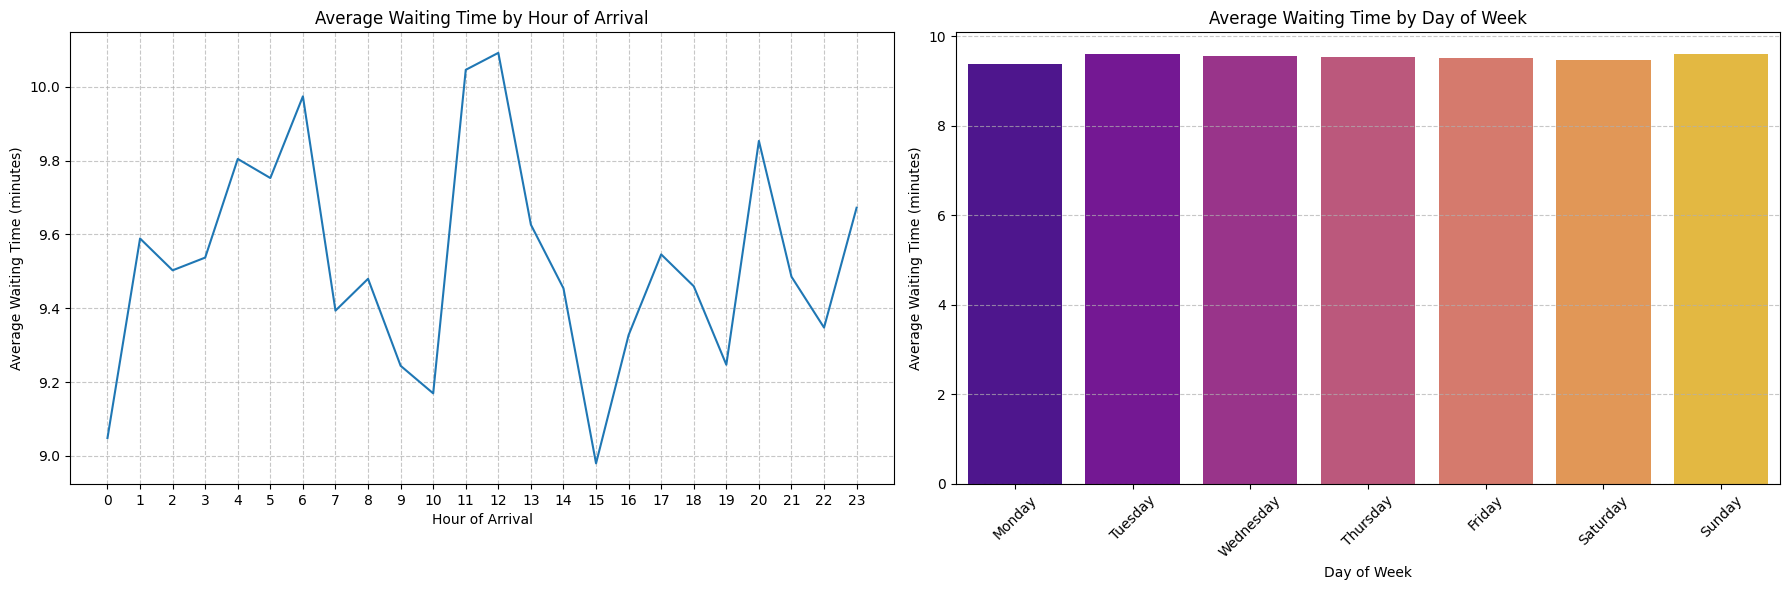

In [ ]:
#Waiting Time Analysis by Hour and Day of Week
#Next, let's explore how waiting times are distributed across different hours and days of the week.

avg_waiting_time_by_hour = df.groupby('arrival_hour')['waiting_time'].mean().reset_index()
avg_waiting_time_by_day = df.groupby('arrival_day_of_week')['waiting_time'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(x='arrival_hour', y='waiting_time', data=avg_waiting_time_by_hour, ax=axes[0])
axes[0].set_title('Average Waiting Time by Hour of Arrival')
axes[0].set_xlabel('Hour of Arrival')
axes[0].set_ylabel('Average Waiting Time (minutes)')
axes[0].set_xticks(range(24))
axes[0].grid(True, linestyle='--', alpha=0.7)

avg_waiting_time_by_day['day_of_week_name'] = avg_waiting_time_by_day['arrival_day_of_week'].map(lambda x: day_names[x])
sns.barplot(x='day_of_week_name', y='waiting_time', data=avg_waiting_time_by_day, ax=axes[1], palette='plasma')
axes[1].set_title('Average Waiting Time by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Waiting Time (minutes)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df['soc_difference'] = df['final_soc'] - df['initial_soc']

# Display the new feature along with the original SOC columns
df[['initial_soc', 'final_soc', 'soc_difference']].head()

,initial_soc,final_soc,soc_difference
0,50.505670,98.931113,48.425443
1,37.142466,100.000000,62.857534
2,23.615366,100.000000,76.384634
3,11.106178,99.518012,88.411834
4,34.663842,100.000000,65.336158


In [ ]:

## interation features

df['price_x_demand'] = df['electricity_price'] * df['charging_demand']
df['queue_x_station_load'] = df['queue_length'] * df['station_load']

df[['electricity_price', 'charging_demand', 'price_x_demand', 'queue_length', 'station_load', 'queue_x_station_load']].head()

,electricity_price,charging_demand,price_x_demand,queue_length,station_load,queue_x_station_load
0,11.28,10.813106,121.971841,5,15.103697,75.518486
1,6.39,80.596952,515.014524,6,79.396225,476.377348
2,9.98,33.353569,332.868623,8,34.301089,274.408709
3,5.01,22.735569,113.905201,8,23.050175,184.401400
4,5.31,63.514166,337.260221,1,63.887936,63.887936


In [ ]:

### feature scaling has been done here


from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# Exclude any binary columns created by one-hot encoding, and temporary/original time columns
scaled_numerical_cols = ['waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc',
                         'energy_consumed_kWh', 'charging_power_kW', 'charging_duration',
                         'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio',
                         'charging_demand', 'soc_difference', 'total_charging_time',
                         'price_x_demand', 'queue_x_station_load']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df[scaled_numerical_cols] = scaler.fit_transform(df[scaled_numerical_cols])

print("Scaled numerical columns:")
df[scaled_numerical_cols].head()

Scaled numerical columns:


,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,soc_difference,total_charging_time,price_x_demand,queue_x_station_load
0,0.505474,-0.843200,1.084214,0.133698,-1.038836,-0.918910,-0.084972,0.144381,-1.390612,0.458571,-1.052004,-1.536297,-1.028393,-0.081818,-1.262870,-0.796766
1,1.731526,-0.043189,0.161211,0.461795,-0.071957,-0.680991,0.186714,0.497885,0.957622,-1.240156,-0.085387,0.995613,-0.055899,0.186442,-0.041827,1.038269
2,-0.516236,-0.843200,-0.773111,0.461795,-0.449376,-0.026714,-0.635554,1.204895,-0.689442,0.006967,-1.256848,-0.718480,0.855613,-0.638457,-0.607689,0.113705
3,0.301132,1.556832,-1.637127,0.313848,2.600155,-0.680991,2.035696,1.204895,-1.100373,-1.719551,-1.108954,-1.103724,1.666055,2.037434,-1.287931,-0.298326
4,1.118500,-1.243205,-0.009988,0.461795,-1.026678,1.638719,-1.020120,-1.269638,0.391194,-1.615335,-0.949808,0.375812,0.111121,-1.020727,-0.594046,-0.850008


In [ ]:
df.columns.tolist()

['station_id',
 'location_type',
 'vehicle_id',
 'vehicle_type',
 'arrival_time',
 'charging_start_time',
 'charging_end_time',
 'waiting_time',
 'battery_capacity_kWh',
 'initial_soc',
 'final_soc',
 'energy_consumed_kWh',
 'charging_power_kW',
 'charging_duration',
 'queue_length',
 'station_load',
 'electricity_price',
 'renewable_energy_ratio',
 'traffic_density',
 'weather_condition',
 'day_of_week',
 'time_slot',
 'charging_demand',
 'assigned_charger_id',
 'charging_priority',
 'optimization_reward',
 'total_charging_time',
 'arrival_day_of_week',
 'charging_start_day_of_week',
 'charging_end_day_of_week',
 'arrival_day_of_week_name',
 'arrival_hour',
 'charging_start_hour',
 'is_weekend',
 'lag_1_hr_station_load',
 'lag_2_hr_station_load',
 'lag_3_hr_station_load',
 'lag_24_hr_station_load',
 'rolling_avg_3hr_',
 'date',
 'soc_difference',
 'price_x_demand',
 'queue_x_station_load']

In [ ]:
## dropping original columns

columns_to_drop = ['charging_start_time', 'charging_end_time', 'vehicle_id', 'assigned_charger_id']
# Filter columns_to_drop to only include those present in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop)

print("DataFrame after dropping original time and ID columns:")
df.head()

DataFrame after dropping original time and ID columns:


,station_id,location_type,vehicle_type,arrival_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,...,is_weekend,lag_1_hr_station_load,lag_2_hr_station_load,lag_3_hr_station_load,lag_24_hr_station_load,rolling_avg_3hr_,date,soc_difference,price_x_demand,queue_x_station_load
0,ST001,Highway,Bus,2025-01-01 06:45:00,0.505474,-0.843200,1.084214,0.133698,-1.038836,-0.918910,...,0,0.000000,0.0,0.0,0.0,0.0,2025-01-01,-1.028393,-1.262870,-0.796766
1,ST001,Urban,Bus,2025-01-01 18:15:00,1.731526,-0.043189,0.161211,0.461795,-0.071957,-0.680991,...,0,0.000000,0.0,0.0,0.0,0.0,2025-01-01,-0.055899,-0.041827,1.038269
2,ST001,Urban,Bus,2025-01-01 22:45:00,-0.516236,-0.843200,-0.773111,0.461795,-0.449376,-0.026714,...,0,0.000000,0.0,0.0,0.0,0.0,2025-01-01,0.855613,-0.607689,0.113705
3,ST001,Highway,Two-Wheeler,2025-01-02 05:00:00,0.301132,1.556832,-1.637127,0.313848,2.600155,-0.680991,...,0,0.000000,0.0,0.0,0.0,0.0,2025-01-02,1.666055,-1.287931,-0.298326
4,ST001,Urban,Bus,2025-01-02 08:15:00,1.118500,-1.243205,-0.009988,0.461795,-1.026678,1.638719,...,0,15.103697,0.0,0.0,0.0,0.0,2025-01-02,0.111121,-0.594046,-0.850008


In [ ]:
######## EDA ( univariate , bivariate, multivariate analyses)

numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(numeric_columns)
print(categorical_columns)


['waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'day_of_week', 'charging_demand', 'optimization_reward', 'total_charging_time', 'arrival_day_of_week', 'charging_start_day_of_week', 'charging_end_day_of_week', 'arrival_hour', 'charging_start_hour', 'is_weekend', 'lag_1_hr_station_load', 'lag_2_hr_station_load', 'lag_3_hr_station_load', 'lag_24_hr_station_load', 'rolling_avg_3hr_', 'soc_difference', 'price_x_demand', 'queue_x_station_load']
['station_id', 'location_type', 'vehicle_type', 'traffic_density', 'weather_condition', 'time_slot', 'charging_priority', 'arrival_day_of_week_name', 'date']


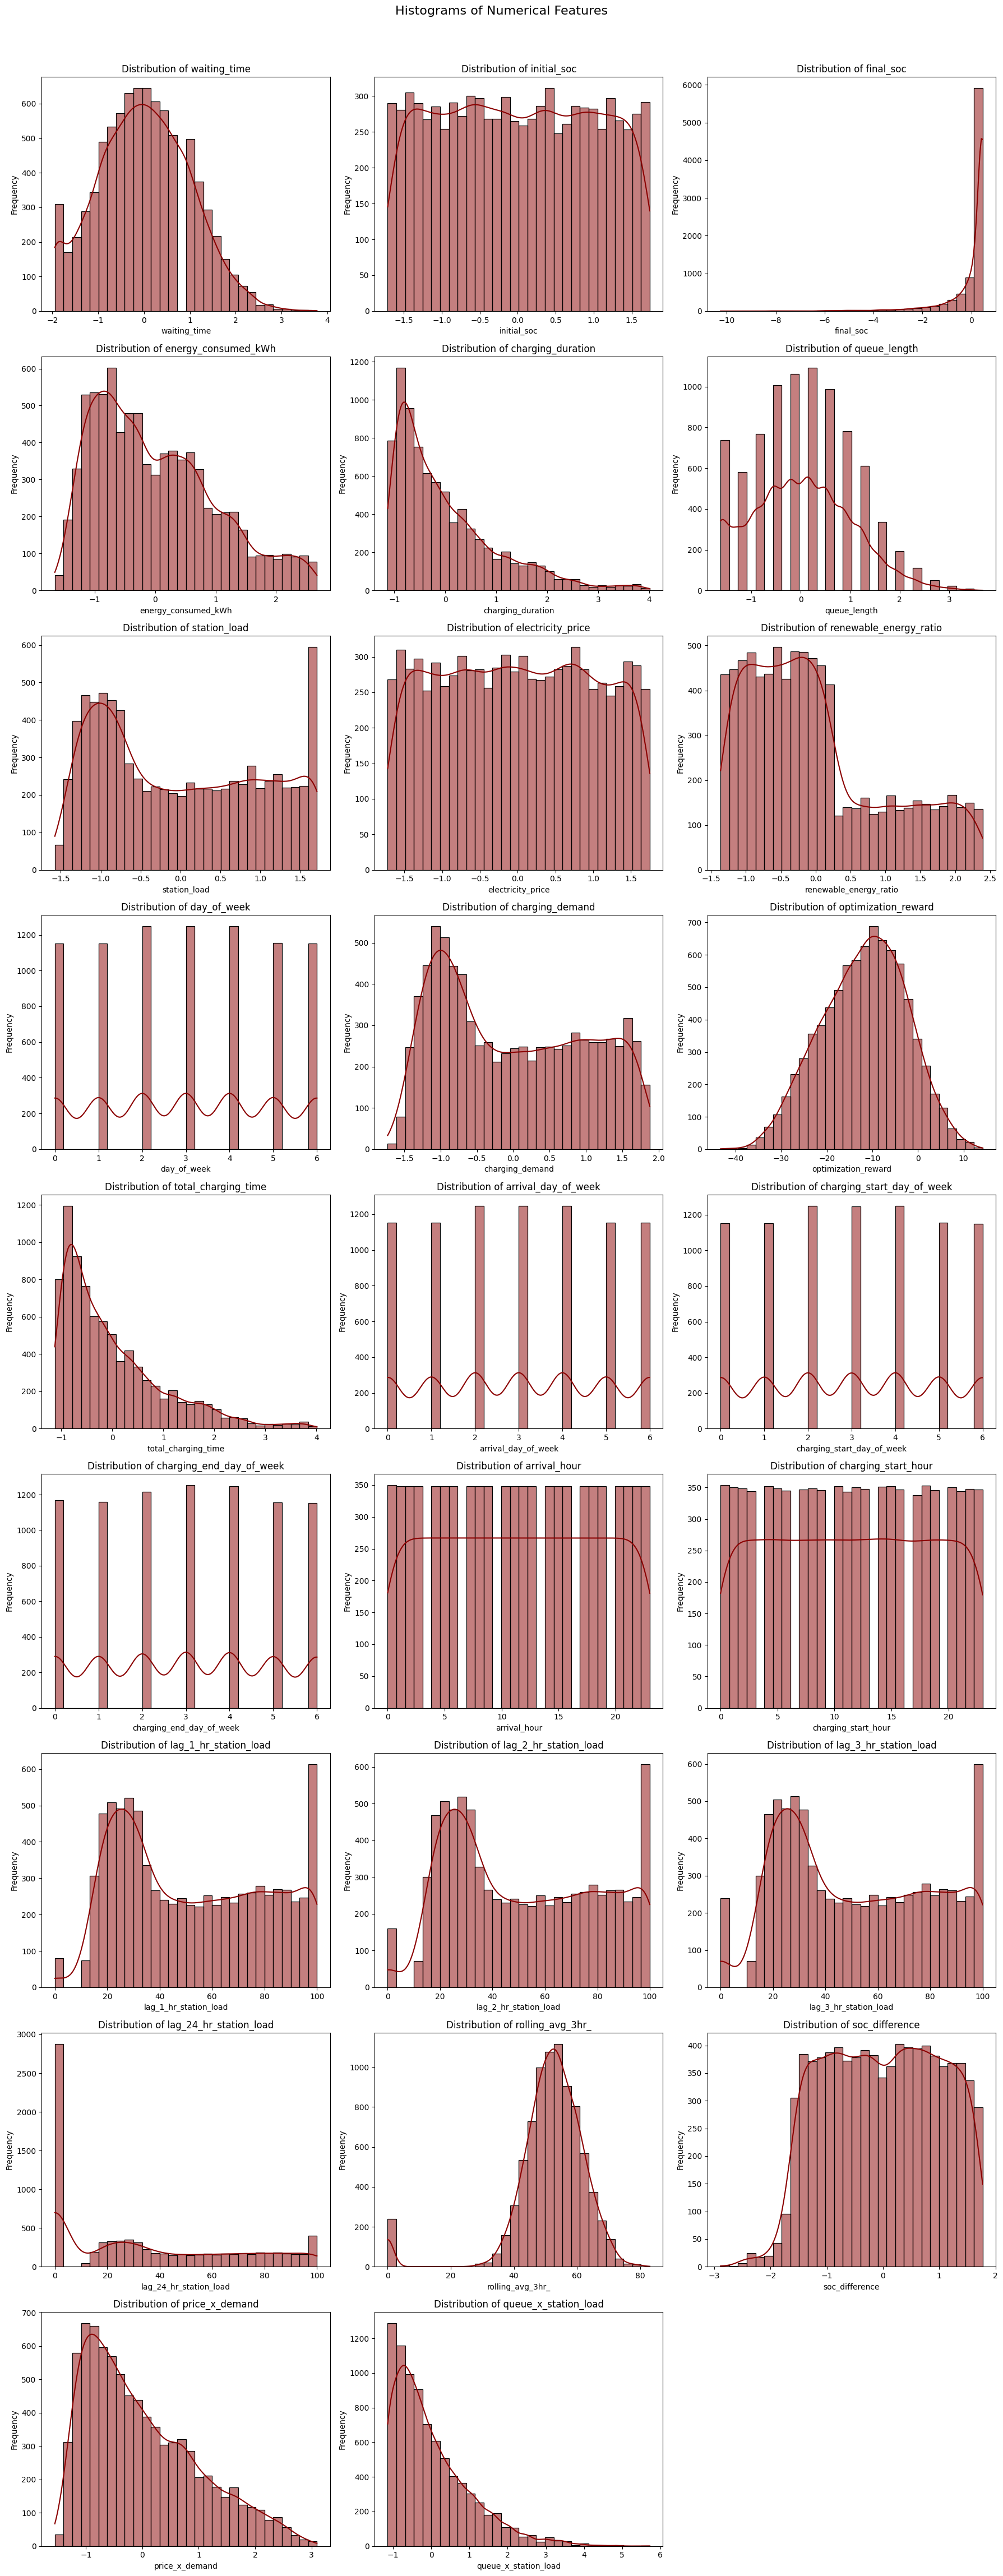

In [ ]:
####### univariate analyses

import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

# Exclude binary columns or columns with very few unique values that aren't suitable for histograms
histogram_cols = [col for col in numerical_columns if df[col].nunique() > 5 and col not in ['is_weekend', 'is_dangerous_spike']]

# Determine grid size for subplots
num_cols = len(histogram_cols)
num_rows = (num_cols + 2) // 3 # Roughly 3 plots per row

plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(histogram_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='darkred')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.show()

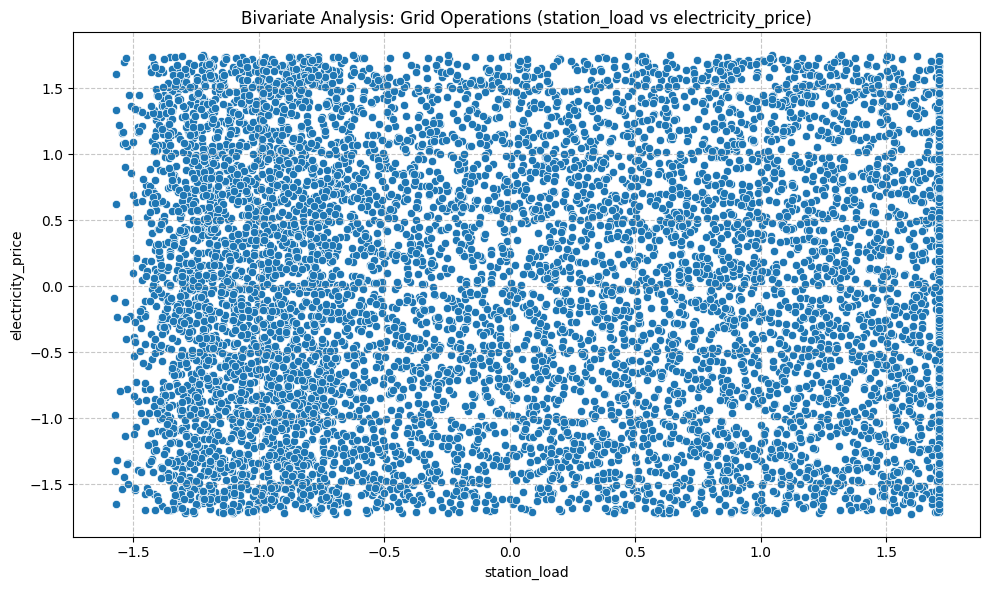

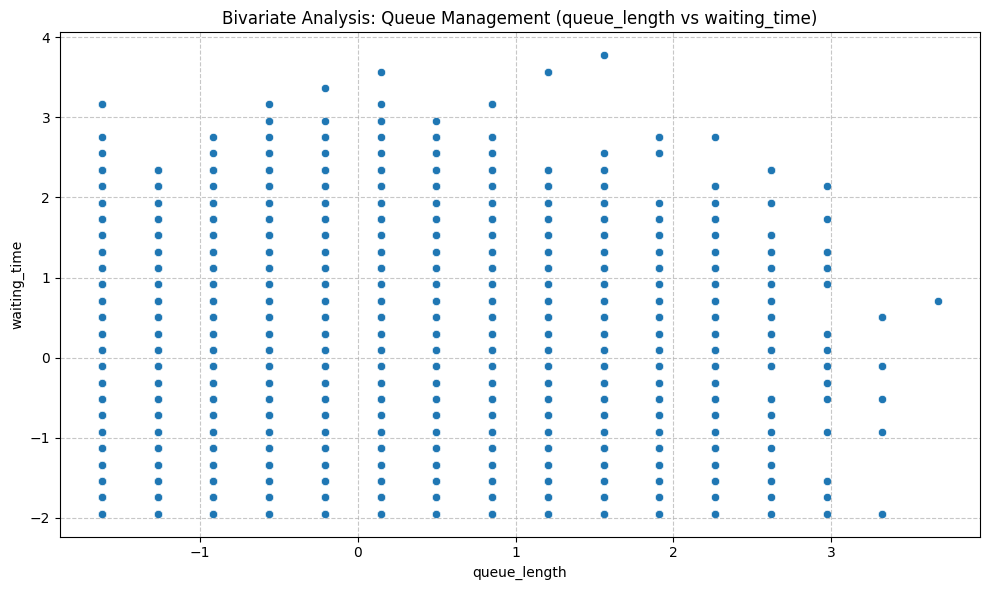

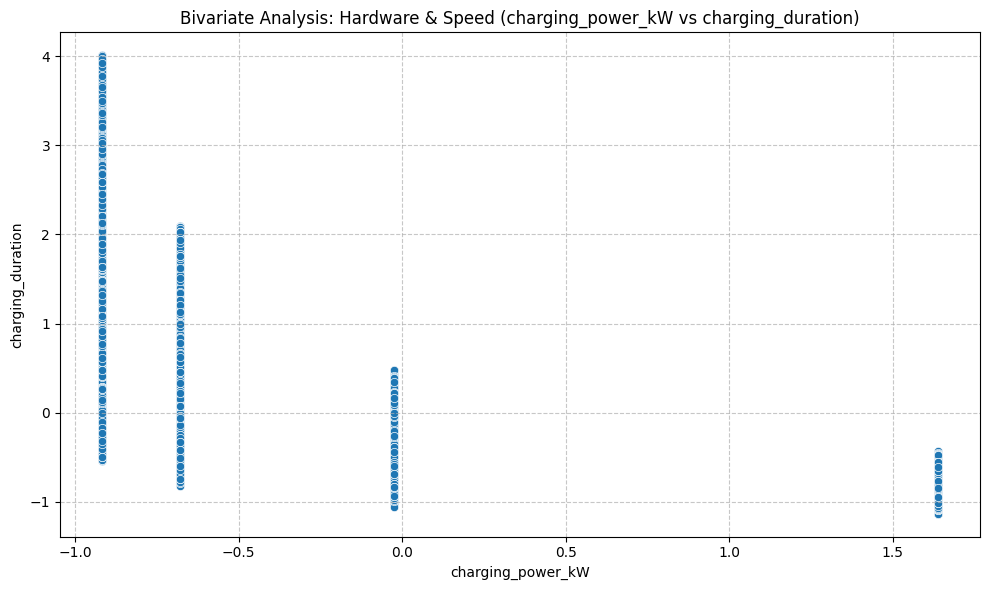

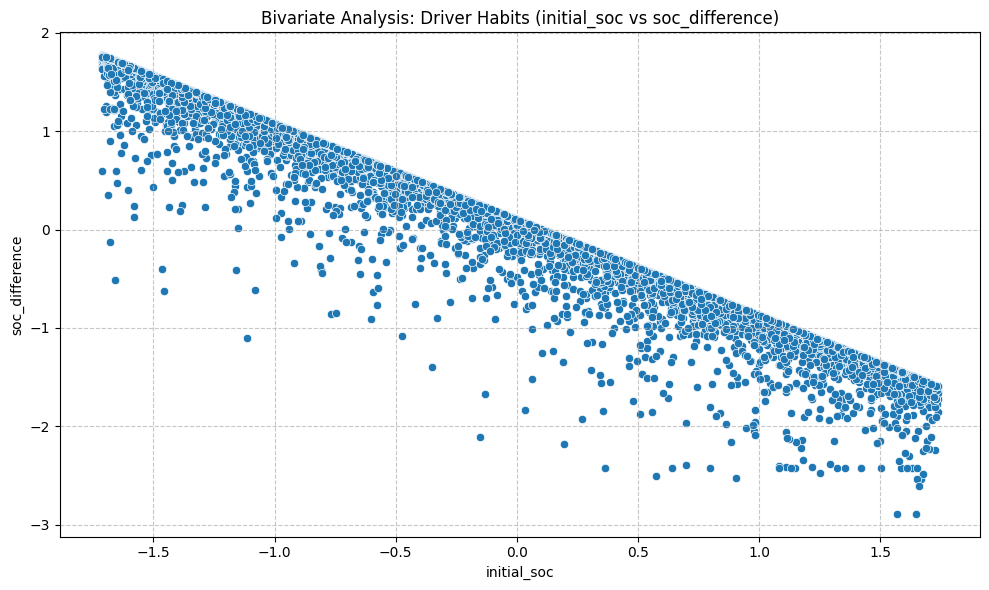

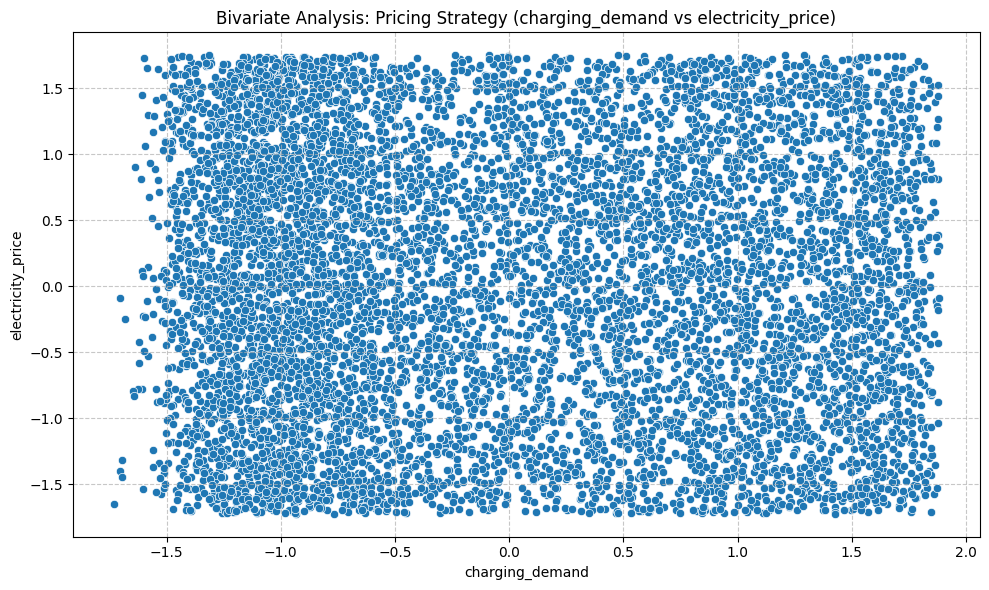

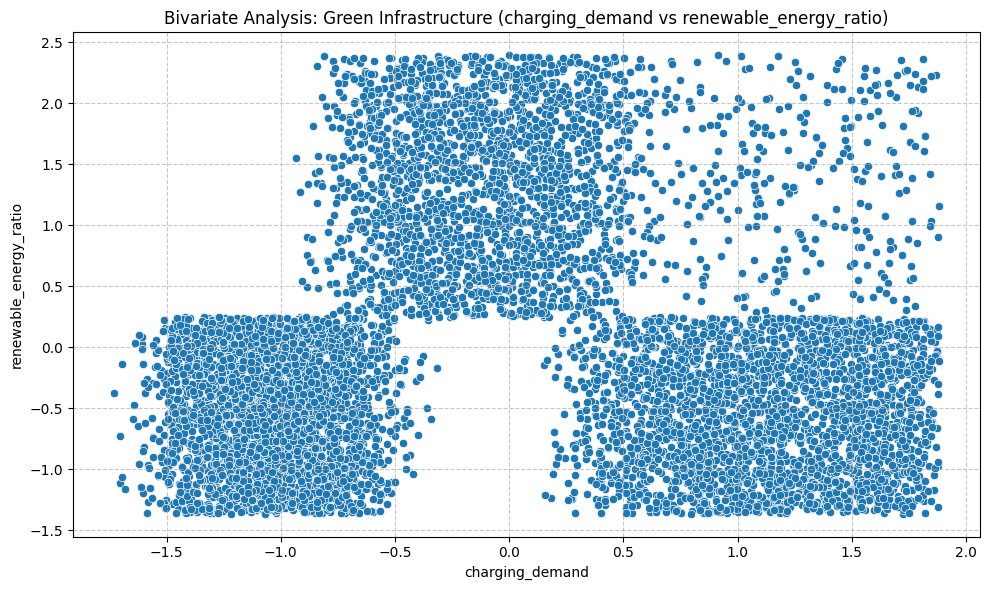

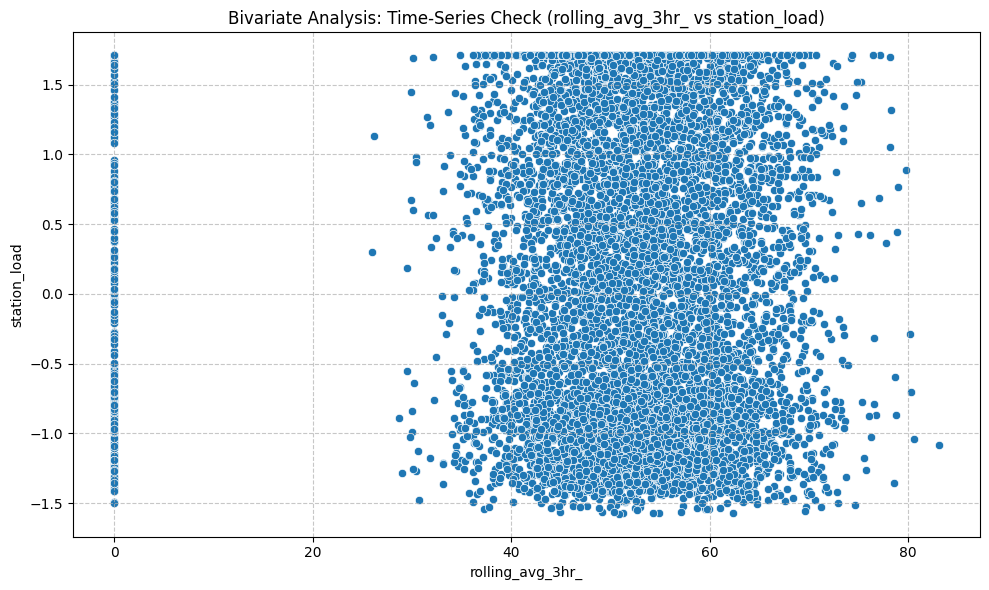

In [ ]:
#### bivariate analyses
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pairs_for_bivariate_analysis = [
    ('station_load', 'electricity_price', 'Grid Operations'),
    ('queue_length', 'waiting_time', 'Queue Management'),
    ('charging_power_kW', 'charging_duration', 'Hardware & Speed'),
    ('initial_soc', 'soc_difference', 'Driver Habits'),
    ('charging_demand', 'electricity_price', 'Pricing Strategy'),
    ('charging_demand', 'renewable_energy_ratio', 'Green Infrastructure'),
    ('rolling_avg_3hr_', 'station_load', 'Time-Series Check')
]

for col1, col2, title_category in pairs_for_bivariate_analysis:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df[col1], y=df[col2])
    plt.title(f'Bivariate Analysis: {title_category} ({col1} vs {col2})')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



In [ ]:
## multivariate analaysis

### Box Plots for Numerical Features

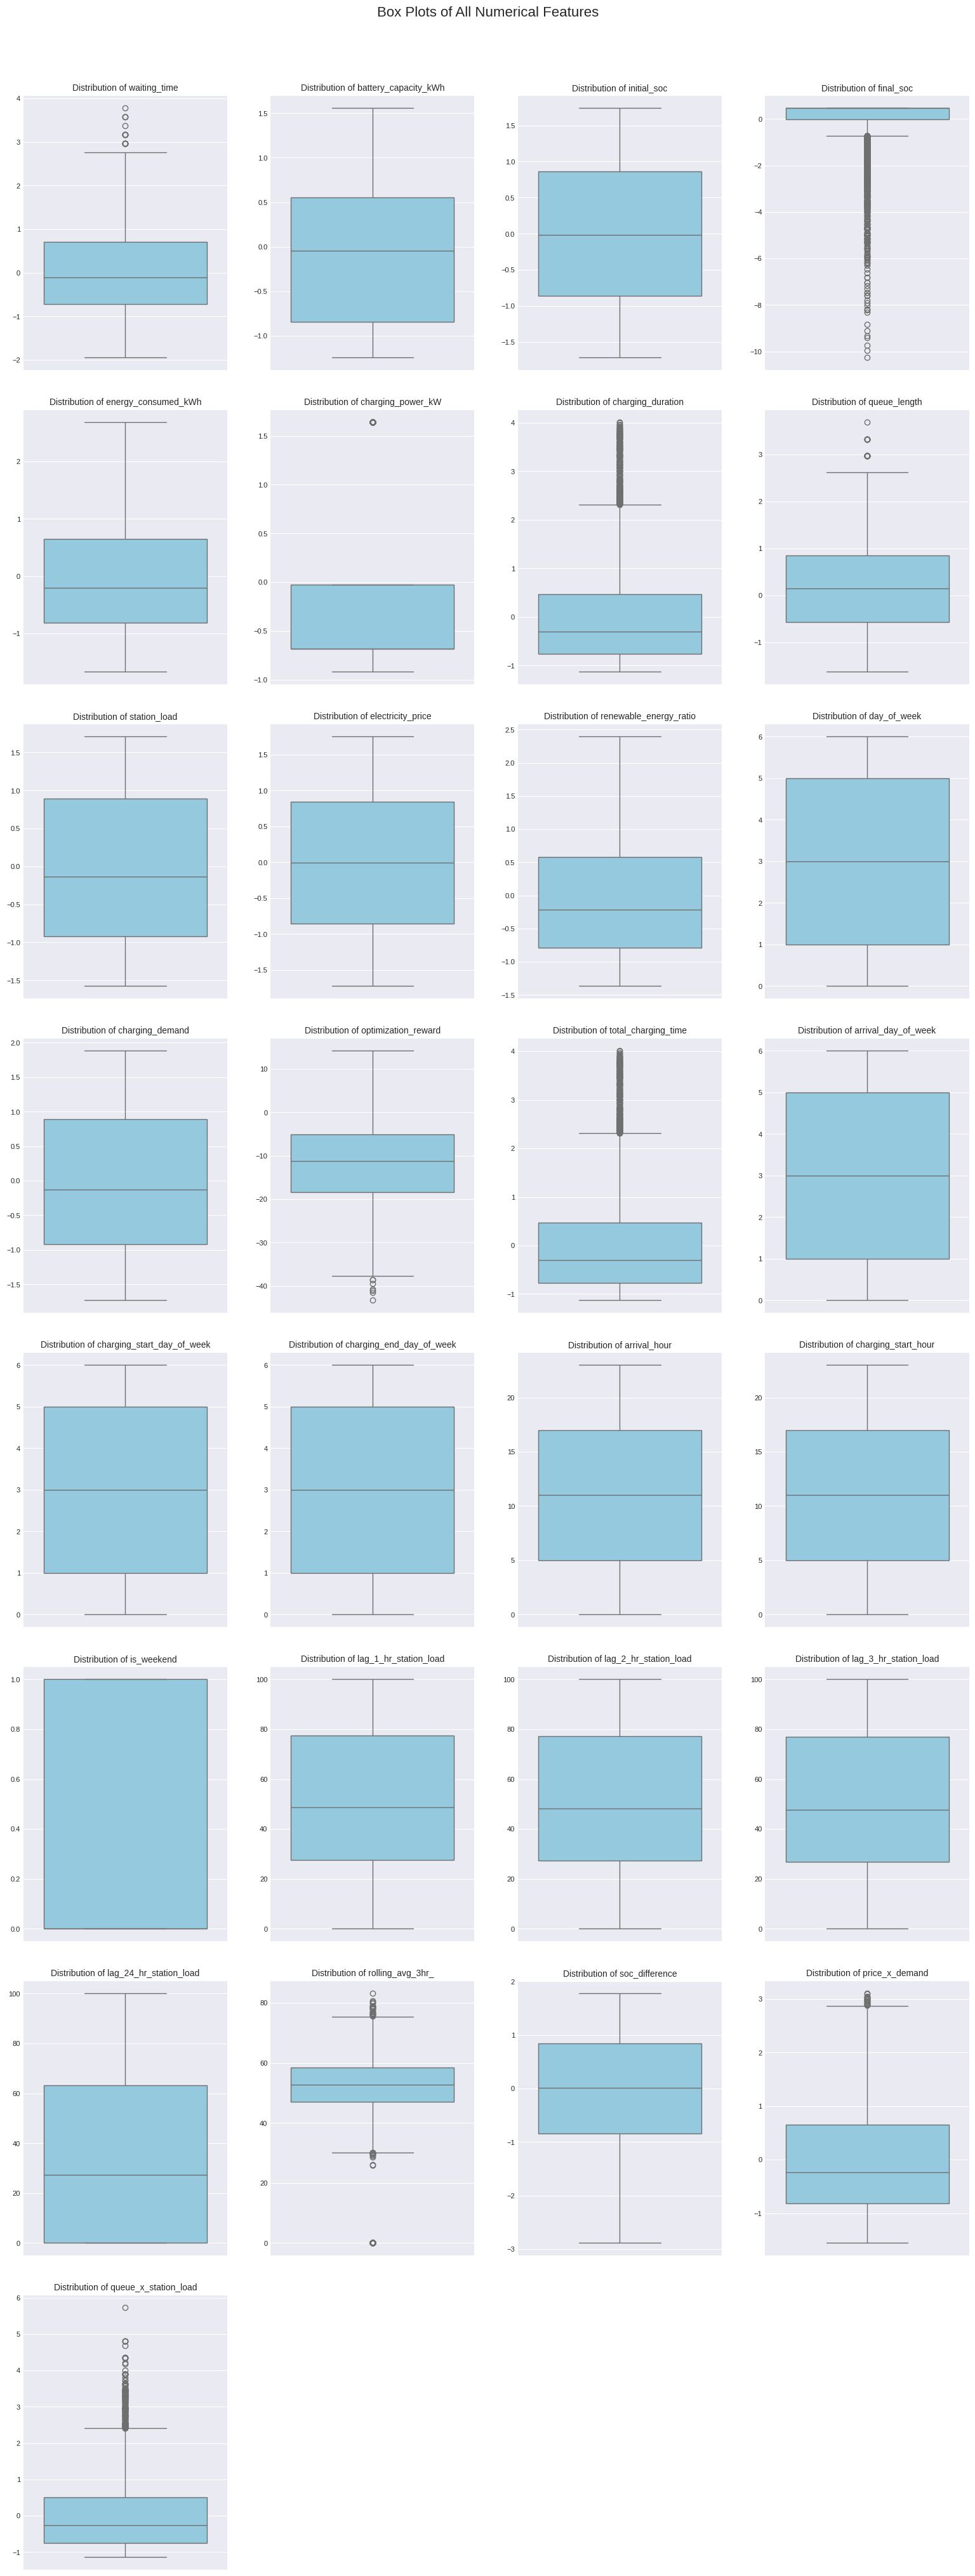

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all numerical columns again, as the previous list might be stale
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

plt.style.use('seaborn-v0_8-darkgrid')

# Create box plots for each numerical column
# We'll arrange them in a grid for better visualization
num_cols_per_row = 4
num_rows = (len(numerical_columns) + num_cols_per_row - 1) // num_cols_per_row

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(4 * num_cols_per_row, 5 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_columns):
    if i < len(axes): # Ensure we don't go out of bounds if there are fewer plots than subplots
        sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribution of {col}', fontsize=10)
        axes[i].set_ylabel('') # Remove y-label to avoid clutter
        axes[i].tick_params(axis='y', labelsize=8)

# Hide any unused subplots
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.suptitle('Box Plots of All Numerical Features', y=1.02, fontsize=16)
plt.show()

In [ ]:
## baseline modeling


In [ ]:
# Pick one station, sort by time, inspect manually
check = df[df['station_id'] == 'ST001'].sort_values(['date', 'arrival_hour'])
check['formatted_arrival_hour'] = check['arrival_hour'].apply(lambda x: f'{x:02d}:00')
check[['date', 'formatted_arrival_hour', 'station_load', 'lag_1_hr_station_load']].head(15)

,date,formatted_arrival_hour,station_load,lag_1_hr_station_load
0,2025-01-01,06:00,-1.390612,0.000000
1,2025-01-01,18:00,0.957622,0.000000
2,2025-01-01,22:00,-0.689442,0.000000
3,2025-01-02,05:00,-1.100373,0.000000
4,2025-01-02,08:00,0.391194,15.103697
5,2025-01-02,17:00,0.850840,79.396225
6,2025-01-02,17:00,0.557965,34.301089
7,2025-01-03,03:00,-0.981458,23.050175
8,2025-01-03,12:00,-0.333760,63.887936
9,2025-01-03,15:00,-0.332516,76.472645


In [ ]:
df

,station_id,location_type,vehicle_type,arrival_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,...,is_weekend,lag_1_hr_station_load,lag_2_hr_station_load,lag_3_hr_station_load,lag_24_hr_station_load,rolling_avg_3hr_,date,soc_difference,price_x_demand,queue_x_station_load
0,ST001,Highway,Bus,2025-01-01 06:45:00,0.505474,-0.843200,1.084214,0.133698,-1.038836,-0.918910,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,2025-01-01,-1.028393,-1.262870,-0.796766
1,ST001,Urban,Bus,2025-01-01 18:15:00,1.731526,-0.043189,0.161211,0.461795,-0.071957,-0.680991,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,2025-01-01,-0.055899,-0.041827,1.038269
2,ST001,Urban,Bus,2025-01-01 22:45:00,-0.516236,-0.843200,-0.773111,0.461795,-0.449376,-0.026714,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,2025-01-01,0.855613,-0.607689,0.113705
3,ST001,Highway,Two-Wheeler,2025-01-02 05:00:00,0.301132,1.556832,-1.637127,0.313848,2.600155,-0.680991,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,2025-01-02,1.666055,-1.287931,-0.298326
4,ST001,Urban,Bus,2025-01-02 08:15:00,1.118500,-1.243205,-0.009988,0.461795,-1.026678,1.638719,...,0,15.103697,0.000000,0.000000,0.000000,0.000000,2025-01-02,0.111121,-0.594046,-0.850008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8349,ST020,Highway,Two-Wheeler,2025-03-27 19:00:00,1.527184,1.556832,-0.614650,0.461795,1.845315,-0.026714,...,0,82.748149,100.000000,100.000000,20.450884,69.996645,2025-03-27,0.701020,-0.706527,-1.142472
8350,ST020,Urban,Two-Wheeler,2025-03-27 21:00:00,0.301132,0.556819,-1.325325,0.461795,1.275774,-0.918910,...,0,87.376111,64.540234,77.936670,74.189810,66.790641,2025-03-27,1.394344,1.336500,1.059473
8351,ST020,Urban,Car,2025-03-28 05:15:00,-1.129262,-0.843200,1.588591,0.461795,-1.170255,-0.918910,...,0,83.609778,75.042534,28.955925,43.878452,68.312739,2025-03-28,-1.448430,-1.108108,-1.002946
8352,ST020,Urban,Car,2025-03-28 14:45:00,0.709816,-0.043189,-0.187676,0.461795,0.087783,1.638719,...,0,76.161642,27.074395,36.514301,35.953309,68.439657,2025-03-28,0.284470,-0.465443,-0.934742


In [ ]:
df.columns.tolist()

['station_id',
 'location_type',
 'vehicle_type',
 'arrival_time',
 'waiting_time',
 'battery_capacity_kWh',
 'initial_soc',
 'final_soc',
 'energy_consumed_kWh',
 'charging_power_kW',
 'charging_duration',
 'queue_length',
 'station_load',
 'electricity_price',
 'renewable_energy_ratio',
 'traffic_density',
 'weather_condition',
 'day_of_week',
 'time_slot',
 'charging_demand',
 'charging_priority',
 'optimization_reward',
 'total_charging_time',
 'arrival_day_of_week',
 'charging_start_day_of_week',
 'charging_end_day_of_week',
 'arrival_day_of_week_name',
 'arrival_hour',
 'charging_start_hour',
 'is_weekend',
 'lag_1_hr_station_load',
 'lag_2_hr_station_load',
 'lag_3_hr_station_load',
 'lag_24_hr_station_load',
 'rolling_avg_3hr_',
 'date',
 'soc_difference',
 'price_x_demand',
 'queue_x_station_load']

In [ ]:
################## learning to train the model on sample data

In [ ]:

#### selecting features

y=df.battery_capacity_kWh
some_feature=['initial_soc','final_soc','charging_duration','station_load','electricity_price','energy_consumed_kWh']
X=df[some_feature]
X.describe()

,initial_soc,final_soc,charging_duration,station_load,electricity_price,energy_consumed_kWh
count,8.354000e+03,8.354000e+03,8.354000e+03,8.354000e+03,8.354000e+03,8.354000e+03
mean,3.200164e-17,-1.035960e-15,-2.125292e-16,1.360867e-16,-2.373012e-16,-1.181190e-16
std,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00,1.000060e+00
min,-1.713491e+00,-1.025702e+01,-1.131370e+00,-1.575084e+00,-1.723025e+00,-1.664364e+00
25%,-8.589922e-01,-9.785311e-03,-7.684334e-01,-9.184994e-01,-8.510814e-01,-8.119275e-01
50%,-1.170454e-02,4.612493e-01,-3.017881e-01,-1.371888e-01,-1.717811e-03,-2.072110e-01
75%,8.635322e-01,4.617947e-01,4.643889e-01,8.920324e-01,8.467773e-01,6.474392e-01
max,1.739471e+00,4.617947e-01,4.009417e+00,1.710158e+00,1.750854e+00,2.680125e+00


In [ ]:
# preparing model and importing libraries and tools requires
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

EV_model= DecisionTreeRegressor(random_state=1)
EV_model.fit(X,y)

DecisionTreeRegressor(random_state=1)

In [ ]:
print("making small prediction model over sample data")
print(X.head())
print("the predictions are")
print(EV_model.predict(X.head()))

making small prediction model over sample data
   initial_soc  final_soc  charging_duration  station_load  electricity_price  \
0     1.084214   0.133698          -0.084972     -1.390612           0.458571   
1     0.161211   0.461795           0.186714      0.957622          -1.240156   
2    -0.773111   0.461795          -0.635554     -0.689442           0.006967   
3    -1.637127   0.313848           2.035696     -1.100373          -1.719551   
4    -0.009988   0.461795          -1.020120      0.391194          -1.615335   

   energy_consumed_kWh  
0            -1.038836  
1            -0.071957  
2            -0.449376  
3             2.600155  
4            -1.026678  
the predictions are
[-0.84320012 -0.04318947 -0.84320012  1.55683185 -1.24320545]


In [ ]:
# this is mae before the data is tested on new data
predicted_batter_capacity=EV_model.predict(X)
mean_absolute_error(y,predicted_batter_capacity)

3.1005036207701053e-15

In [ ]:
# data trained on x , tested on y now the mae is little higher as previously
# data was tested on ssame data that it was trained leads to higher accuracy

train_X,val_X,train_y,val_y=train_test_split(X,y,random_state=0)
EV_model=DecisionTreeRegressor()
EV_model.fit(train_X,train_y)
val_predictions=EV_model.predict(val_X)
print("mae of the model is")
print(mean_absolute_error(val_y,val_predictions))

mae of the model is
0.010340013269366944


In [ ]:
# now underfitting and overfitting part

#overfitting : like in decision tree if the nodes are splitted let say in 2^10
#.              every leaf would have least amount of data for training which causes to learn the exact data
#               , the model predicts in very accurately but fails on new data as it has been trained on limited or smllaer data


# underfitting: lets says tree is splitted into 2 or 4 leaves only which causes a lot data per leave to be trained upon which makes
#                 the prediction far away and less accurate

def get_mae(max_leaf_nodes,train_X,train_y,val_X,val_y):
    EV_model=(DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes,random_state=0))
    EV_model.fit(train_X,train_y)
    preds_val=EV_model.predict(val_X)
    mae=mean_absolute_error(val_y,preds_val)
    return(mae)


    # learning to find a sweet spot between underfitting and overfitting


for max_leaf_nodes in [5,50,500,5000]:
      my_mae=get_mae(max_leaf_nodes,train_X,train_y,val_X,val_y)
      print("max leaf nodes: %d \t\t mean abosulte error: %.6f" %(max_leaf_nodes,my_mae))

max leaf nodes: 5 		 mean abosulte error: 0.352001
max leaf nodes: 50 		 mean abosulte error: 0.018104
max leaf nodes: 500 		 mean abosulte error: 0.010819
max leaf nodes: 5000 		 mean abosulte error: 0.010819


In [ ]:
## building a random forest model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

forest_model= RandomForestRegressor(random_state=1)
forest_model.fit(train_X,train_y)
EV_preds= forest_model.predict(val_X)
print(mean_absolute_error(val_y,EV_preds))

0.012129410010147801


### Random Forest Regressor Evaluation

Let's evaluate the Random Forest Regressor with additional metrics like Mean Squared Error (MSE) and R-squared (R2) score.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Assuming `EV_preds` are the predictions from the Random Forest model on `val_X`
# and `val_y` is the true target values for the validation set.

# Mean Absolute Error (already calculated)
mae_rf = mean_absolute_error(val_y, EV_preds)
print(f"Random Forest MAE: {mae_rf:.6f}")

# Mean Squared Error
mse_rf = mean_squared_error(val_y, EV_preds)
print(f"Random Forest MSE: {mse_rf:.6f}")

# R-squared
r2_rf = r2_score(val_y, EV_preds)
print(f"Random Forest R2 Score: {r2_rf:.6f}")

Random Forest MAE: 0.012129
Random Forest MSE: 0.002904
Random Forest R2 Score: 0.997104


### Linear Regression Baseline

Let's add a simple Linear Regression model as another baseline to compare performance.

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(train_X, train_y)

# Make predictions on the validation set
linear_preds = linear_model.predict(val_X)

# Evaluate the Linear Regression model
mae_lr = mean_absolute_error(val_y, linear_preds)
mse_lr = mean_squared_error(val_y, linear_preds)
r2_lr = r2_score(val_y, linear_preds)

print(f"Linear Regression MAE: {mae_lr:.6f}")
print(f"Linear Regression MSE: {mse_lr:.6f}")
print(f"Linear Regression R2 Score: {r2_lr:.6f}")

Linear Regression MAE: 0.166854
Linear Regression MSE: 0.050697
Linear Regression R2 Score: 0.949438


### Support Vector Regressor (SVR) Baseline

Finally, let's include a Support Vector Regressor to see how a kernel-based method performs.

In [ ]:
from sklearn.svm import SVR

# Initialize and train the SVR model (using a linear kernel for simplicity as a baseline)
# Note: SVR can be computationally expensive; consider scaling data if not already done for SVR.
# (Data has already been scaled in a previous step, which is good for SVR)
svr_model = SVR(kernel='linear')
svr_model.fit(train_X, train_y)

# Make predictions on the validation set
svr_preds = svr_model.predict(val_X)

# Evaluate the SVR model
mae_svr = mean_absolute_error(val_y, svr_preds)
mse_svr = mean_squared_error(val_y, svr_preds)
r2_svr = r2_score(val_y, svr_preds)

print(f"SVR MAE: {mae_svr:.6f}")
print(f"SVR MSE: {mse_svr:.6f}")
print(f"SVR R2 Score: {r2_svr:.6f}")

SVR MAE: 0.167329
SVR MSE: 0.051802
SVR R2 Score: 0.948336


### Baseline Model Comparison Summary

We have now evaluated three different baseline models. You can compare their MAE, MSE, and R2 scores to determine which one performs best as a starting point for further optimization or more complex models.

In [ ]:
###################### data cleaning of global_csv file#################

In [ ]:
dff

,StationID,UUID,DataProviderID,Operator,UsageType,UsageCost,AddressTitle,AddressLine1,Town,StateOrProvince,Postcode,Country,Latitude,Longitude,MaxPowerKW,FastChargeCount,ConnectionTypes,StatusType,YearCreated
0,473101,5B1E6265-45A9-4D0E-83A7-AB49D84D0BB2,1,Tesla (including non-tesla),Public,NaN,Tesla Supercharger,Purley Way,NaN,NaN,NaN,United Kingdom,51.371709,-0.116955,250.0,1,CCS (Type 2),Operational,2026
1,472908,A5EA67A8-756B-4C09-B578-BAEC40AEA237,1,Lidl,Public - Membership Required,£0.57/kWh,Positive Energy - DoubleTree by Hilton Manches...,Outwood Road,Wythenshawe,England,M90 4HL,United Kingdom,53.366453,-2.269799,11.0,0,Type 2 (Socket Only),Operational,2026
2,472220,1CCABB37-2CE5-49D4-8DC0-5025BE976BA1,1,EZO (IE),Public - Membership Required,NaN,Holiday Inn Express,106 University Street,Belfast,NaN,BT7 1HP,United Kingdom,54.586836,-5.926869,50.0,1,CCS (Type 2),Operational,2025
3,471954,0E7B7267-6DEE-4E85-91F4-D11B8FF789A9,1,BMM Energy (UK),Public - Membership Required,NaN,South Tyrone Hospital,Carland Road,Dungannon,NaN,BT71 4AU,United Kingdom,54.509453,-6.768057,22.0,0,Type 2 (Socket Only),Operational,2025
4,471953,A4E4A241-BF88-4394-99B2-B0B788FE3287,1,BMM Energy (UK),Public - Membership Required,NaN,Armagh Community Hospital,Victoria Grove,Armagh,NaN,BT61 9DH,United Kingdom,54.350644,-6.641787,22.0,0,Type 2 (Socket Only),Operational,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257580,267627,6152215D-9092-4602-B8BD-83190BB84042,1,(Unknown Operator),Public,0.4€ per kw,Hypercharger CCS2 & GB/T - EuroJeta Sh.P.K.,Pavarësia,NaN,NaN,23050,Kosovo,42.315385,20.806214,120.0,1,CCS (Type 2),Operational,2023
257581,267517,B3E5A178-946A-4E79-B08B-5B41AF495588,1,(Unknown Operator),Public - Pay At Location,0.15 €/kWh,Hotel Gracanica,Dragana Ristića,Gracanica,NaN,10500,Kosovo,42.600458,21.186628,22.0,0,Type 2 (Socket Only),Operational,2023
257582,147836,0DCB853D-A434-4B51-A295-DC73D5EC3BEC,1,(Business Owner at Location),Public,0.29€\kWh,Shell Prishtina,Rrafshi i Kosovës,Çagllavicë (Prishtinë),Municipality of Pristina,2071,Kosovo,42.631876,21.145781,50.0,2,"CCS (Type 2), CHAdeMO, Type 2 (Tethered Connec...",Operational,2020
257583,147835,2E5B98D1-6C0D-4E9E-AEE1-805211211358,1,(Business Owner at Location),Public,Free,HIB Petrol Caglavice,Prishtina-Skopje Highway; Prishtinë,NaN,Municipality of Gračanica / Graçanica,NaN,Kosovo,42.603811,21.132543,50.0,2,"CCS (Type 2), CHAdeMO, Type 2 (Tethered Connec...",Operational,2020
